# NIVARIA Gasifier — Step 2: Heater Power Cross-Validation

**Objective**: verify that the heater powers identified in Step 1 (from case idx=2) correctly
predict the wall temperature evolution observed in an independent experiment:

- **Case idx=3** — `20260202_NIVARIA_prueba_15 sin cribar` (≈67 min pre-flow)

## Validation approach

For each case:
1. Extract the pre-flow segment (no biomass, no N₂ flow)
2. Initialise the wall and gas temperatures from the sensor readings at t=0 of that segment
3. Simulate with the **same** Q_bottom, Q_middle, Q_top from Step 1 (no re-fitting)
4. Compare simulated Tw vs measured temperatures → RMSE, bias, profile plots

A good cross-validation result confirms that the identified powers are physically representative
and not an artefact of over-fitting to a single experiment.

## 1. Imports and configuration

In [18]:
import os, sys, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
EXP  = os.getcwd()   # experimentacion/

for p in [ROOT, EXP]:
    if p not in sys.path:
        sys.path.insert(0, p)

# ── HEATER API ────────────────────────────────────────────────────────────────
from src.units.heater.config.gas_props  import build_gas_prop_config
from src.units.heater.config.boundary_c import build_boundary_c_config
from src.units.heater.config.thermal_bc import build_thermal_bc_config
from src.units.heater.config.transport  import build_transport_config
from src.units.heater.config.initial_c  import build_initial_c_config
from src.units.heater.config.wall_c     import build_wall_config
from src.units.heater.state             import pack_state_vector
from src.solvers.runner_heater          import run_step

# ── Experimental data ─────────────────────────────────────────────────────────
from getDataHeater import (
    process_folder_for_empty_validation,
    build_empty_segments_for_cases,
    build_pre_flow_segments_for_cases,
    build_pre_flow_summary,
    compute_bed_zone_power,
    plot_bed_zone_power,
)

DB_GAS   = os.path.join(ROOT, "materials", "fluids",  "gasdb.txt")
DB_SOLID = os.path.join(ROOT, "materials", "solids", "soliddb.txt")
RAW_DIR  = os.path.join(EXP, "rawData")

print("Imports OK")

Imports OK


## 2. Load Step-1 optimal powers

In [19]:
_powers_path = os.path.join(EXP, "results", "step1_heater_powers.json")

if not os.path.isfile(_powers_path):
    raise FileNotFoundError(
        f"Step-1 results not found at:\n  {_powers_path}\n"
        "Run step_1_heater_power_identification.ipynb first and execute the export cell."
    )

with open(_powers_path) as f:
    step1 = json.load(f)

Q_OPT_B = float(step1["Q_bottom_W"])
Q_OPT_M = float(step1["Q_middle_W"])
Q_OPT_T = float(step1["Q_top_W"])

print("Step-1 optimal powers loaded:")
print(f"  Source case      : [{step1['source_case_idx']}] {step1['source_case_file']}")
print(f"  Q_bottom         : {Q_OPT_B:.1f} W")
print(f"  Q_middle         : {Q_OPT_M:.1f} W")
print(f"  Q_top            : {Q_OPT_T:.1f} W")
print(f"  Q_total          : {step1['Q_total_W']:.1f} W")
print(f"  Fit RMSE (step1) : {step1['RMSE_K']:.3f} K")

Step-1 optimal powers loaded:
  Source case      : [2] 20260128_NIVARIA_prueba_15 sin cribar.xlsx
  Q_bottom         : 206.7 W
  Q_middle         : 130.3 W
  Q_top            : 165.6 W
  Q_total          : 502.6 W
  Fit RMSE (step1) : 8.765 K


## 3. Load experimental data

In [20]:
cases_raw = process_folder_for_empty_validation(RAW_DIR, min_pre_feed_min=5.0)
cases_seg = build_empty_segments_for_cases(cases_raw)

cases_pf  = build_pre_flow_segments_for_cases(
    cases_seg,
    flow_candidates=["Temp_aire-Ten_QA_0", "Caudal_aire", "Temp_aire-Ten_QS_0"],
    flow_threshold=0.0,
)

summary_pf = build_pre_flow_summary(cases_pf)

# Validation cases
VAL_INDICES = [3]

print("Validation cases:")
print(summary_pf.loc[
    summary_pf["idx"].isin(VAL_INDICES),
    ["idx", "file_name", "ok_pre_flow", "duration_min"]
].to_string(index=False))

Validation cases:
 idx                                  file_name  ok_pre_flow  duration_min
   3 20260202_NIVARIA_prueba_15 sin cribar.xlsx         True          66.8


## 4. Gasifier geometry and simulator setup

In [21]:
# Geometry (identical to step_1)
L   = 0.75    # m
Di  = 0.08    # m
Do  = 0.09    # m
N   = 3

e_wall = (Do - Di) / 2.0
dz     = L / N
Ai     = 0.25 * np.pi * Di**2
Pi     = np.pi * Di
Po     = np.pi * Do

nc      = 1
SPECIES = ["N2"]
RTOL    = 1.0e-6
ATOL    = 1.0e-8
N_SEC   = 20
P_INIT  = 1.01325   # bar
V_IN    = 0.001     # m/s — virtually static

TEMP_COLS = {
    "TG_1": "Temp_aire-Ten_TG_1",
    "TG_2": "Temp_aire-Ten_TG_2",
    "TG_3": "Temp_aire-Ten_TG_3",
}


def _init_temp(arr: np.ndarray, n_head: int = 5) -> float:
    """Mean of the first n_head finite values found anywhere in arr.

    Scans the full array to handle arbitrarily long NaN runs at segment start
    (logging gaps, sensor warm-up, etc.).
    Raises if the array contains no finite value at all.
    """
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        raise ValueError("Temperature array contains no finite values.")
    return float(np.mean(finite[:n_head]))


def simulate_case(case, Q_bottom, Q_middle, Q_top):
    """
    Run a pre-flow simulation for a given case using the supplied heater powers.

    Initial conditions are taken from the first finite samples of the pre-flow
    segment (wall and gas temperatures).

    Returns
    -------
    t_exp_s   : ndarray  — experimental time vector [s]
    T_exp_K   : dict     — measured temperatures per zone [K]
    t_sim     : ndarray  — simulated time vector [s]
    h         : HeaterResults
    cpu_s     : float    — CPU time [s]
    """
    df_pf = case["dfs"]["process_pre_flow"].copy()

    t_exp_s = df_pf["x_min"].values * 60.0
    T_exp_K = {
        lbl: pd.to_numeric(df_pf[col], errors="coerce").values + 273.15
        for lbl, col in TEMP_COLS.items()
    }
    T_MAX_s = float(t_exp_s[-1])

    # Initial temperatures: mean of first finite samples (robust to leading NaN)
    Tw_init = np.array([
        _init_temp(T_exp_K["TG_1"]),
        _init_temp(T_exp_K["TG_2"]),
        _init_temp(T_exp_K["TG_3"]),
    ])
    T_gas_init = float(np.mean(Tw_init))

    print(f"  Tw_init [K]: {Tw_init.round(1)}   T_gas_init: {T_gas_init:.1f} K")

    prop_gas  = build_gas_prop_config(
        species=SPECIES, mode="polynomial", n_comp=nc, N=N, db_path=DB_GAS,
    )
    gas_T_ref = float(np.min(np.asarray(prop_gas["Tref"])))

    bc  = build_boundary_c_config(
        n_comp=nc, v_in=V_IN, T_in=T_gas_init,
        y_in=np.array([1.0]), P_out=P_INIT,
    )
    tbc = build_thermal_bc_config(
        mode="heatfluxwall", Di=Di, Do=Do, e_wall=e_wall,
        Qwall=np.array([Q_bottom, Q_middle, Q_top], dtype=float),
    )
    tc  = build_transport_config(mode="correlation", N=N)
    wc  = build_wall_config(
        N=N, Di=Di, Do=Do, T_w_init=Tw_init,
        material_id="SS316L", material_mode="polynomial", db_path=DB_SOLID,
    )
    ic  = build_initial_c_config(
        P_init=P_INIT, Tg_init=T_gas_init, y_init=np.array([1.0]),
        n_comp=nc, N=N, prop_gas=prop_gas, gas_T_ref=gas_T_ref,
        wall_config=wc,
    )
    sv0 = pack_state_vector(ic["C_init"], ic["Hg_init"], Tw=ic["Tw_init"])

    params = {
        "n_comp": nc, "N": N, "dz": dz, "Ai": Ai, "Di": Di, "Pi": Pi, "Po": Po,
        "prop_gas": prop_gas, "MW": np.asarray(prop_gas["MW"]),
        "gas_T_ref": gas_T_ref,
        "bc_config": bc, "trans_config": tc, "thermal_bc_config": tbc,
        "energy": True, "prop_update_mode": "always", "trans_update_mode": "always",
        "species": SPECIES, "wall_config": wc, "_cache": {},
    }

    t0 = time.perf_counter()
    t_sim, _, h = run_step(
        sv0=sv0, t_max=T_MAX_s, params=params,
        solver="solve_ivp", rtol=RTOL, atol=ATOL, n_sec=N_SEC,
    )
    cpu_s = time.perf_counter() - t0

    return t_exp_s, T_exp_K, t_sim, h, cpu_s


print("simulate_case defined OK")

simulate_case defined OK


## 5. Cross-validation simulations

In [22]:
val_results = {}

for idx in VAL_INDICES:
    row = summary_pf[summary_pf["idx"] == idx].iloc[0]
    if not row["ok_pre_flow"]:
        print(f"[idx={idx}] No valid pre-flow segment — skipping.")
        continue

    case = cases_pf[idx]
    print(f"Simulating case [{idx}]: {case['file_name']}")
    print(f"  Pre-flow duration: {row['duration_min']:.2f} min")

    t_exp_s, T_exp_K, t_sim, h, cpu_s = simulate_case(
        case, Q_OPT_B, Q_OPT_M, Q_OPT_T
    )

    # Per-zone RMSE and bias
    metrics = {}
    for i, key in enumerate(["TG_1", "TG_2", "TG_3"]):
        T_sim_i = np.interp(t_exp_s, t_sim, h._Tw_results[:, i])
        err   = T_sim_i - T_exp_K[key]
        valid = np.isfinite(err)
        metrics[key] = {
            "rmse": float(np.sqrt(np.mean(err[valid]**2))),
            "bias": float(np.mean(err[valid])),
            "max_err": float(np.max(np.abs(err[valid]))),
        }
        print(f"  {key}: RMSE={metrics[key]['rmse']:.2f} K  "
              f"Bias={metrics[key]['bias']:+.2f} K  "
              f"MaxErr={metrics[key]['max_err']:.2f} K")

    rmse_mean = float(np.mean([m["rmse"] for m in metrics.values()]))
    print(f"  RMSE mean: {rmse_mean:.2f} K  |  CPU: {cpu_s:.1f} s")
    print()

    val_results[idx] = {
        "case": case,
        "t_exp_s": t_exp_s,
        "T_exp_K": T_exp_K,
        "t_sim":   t_sim,
        "h":       h,
        "metrics": metrics,
        "rmse_mean": rmse_mean,
    }

print("Simulations complete.")

Simulating case [3]: 20260202_NIVARIA_prueba_15 sin cribar.xlsx
  Pre-flow duration: 66.80 min
  Tw_init [K]: [397.4 395.7 403.3]   T_gas_init: 398.8 K
  TG_1: RMSE=29.87 K  Bias=-1.84 K  MaxErr=71.03 K
  TG_2: RMSE=52.95 K  Bias=-22.30 K  MaxErr=102.78 K
  TG_3: RMSE=50.82 K  Bias=-19.24 K  MaxErr=109.85 K
  RMSE mean: 44.55 K  |  CPU: 72.8 s

Simulations complete.


## 6. Results

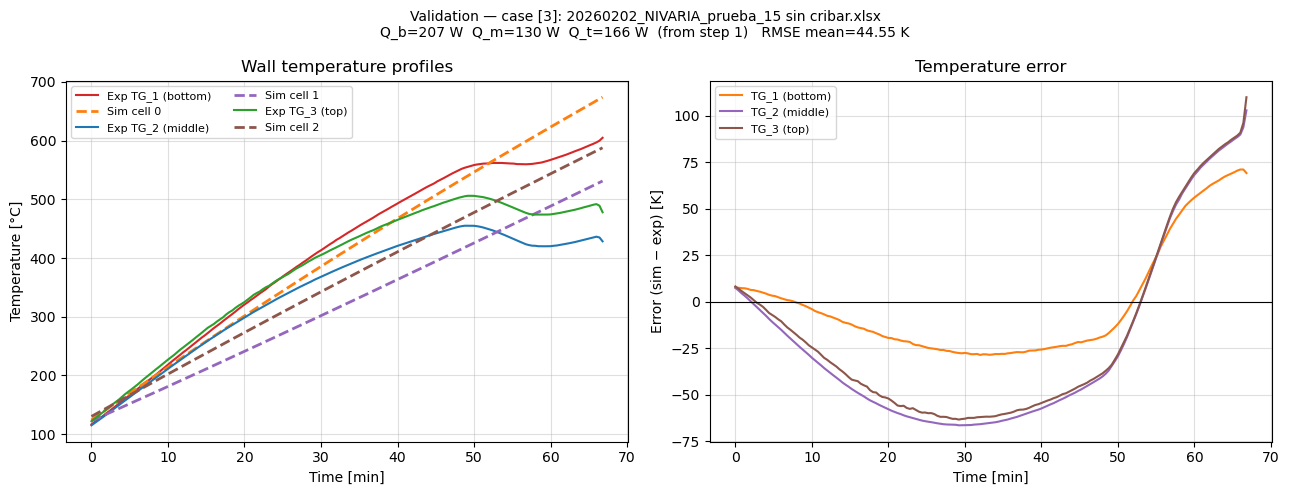

In [23]:
clr_exp = ["#d62728", "#1f77b4", "#2ca02c"]
clr_sim = ["#ff7f0e", "#9467bd", "#8c564b"]
tg_keys = ["TG_1", "TG_2", "TG_3"]
labels  = ["TG_1 (bottom)", "TG_2 (middle)", "TG_3 (top)"]

for idx, vr in val_results.items():
    t_exp_s = vr["t_exp_s"]
    T_exp_K = vr["T_exp_K"]
    t_sim   = vr["t_sim"]
    h       = vr["h"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    for i, (key, lbl) in enumerate(zip(tg_keys, labels)):
        ax.plot(t_exp_s / 60.0, T_exp_K[key] - 273.15,
                color=clr_exp[i], lw=1.5, label=f"Exp {lbl}")
        ax.plot(t_sim / 60.0, h._Tw_results[:, i] - 273.15,
                color=clr_sim[i], lw=2.0, ls="--", label=f"Sim cell {i}")
    ax.set_xlabel("Time [min]")
    ax.set_ylabel("Temperature [°C]")
    ax.set_title("Wall temperature profiles")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=8, ncol=2)

    ax = axes[1]
    for i, (key, lbl, clr) in enumerate(zip(tg_keys, labels, clr_sim)):
        T_sim_i = np.interp(t_exp_s, t_sim, h._Tw_results[:, i])
        err   = T_sim_i - T_exp_K[key]
        valid = np.isfinite(err)
        ax.plot(t_exp_s[valid] / 60.0, err[valid], color=clr, lw=1.5, label=lbl)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("Time [min]")
    ax.set_ylabel("Error (sim − exp) [K]")
    ax.set_title("Temperature error")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=8)

    fig.suptitle(
        f"Validation — case [{idx}]: {vr['case']['file_name']}\n"
        f"Q_b={Q_OPT_B:.0f} W  Q_m={Q_OPT_M:.0f} W  Q_t={Q_OPT_T:.0f} W  "
        f"(from step 1)   RMSE mean={vr['rmse_mean']:.2f} K",
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()

## 7. Summary

In [24]:
print("=" * 66)
print("  CROSS-VALIDATION SUMMARY — NIVARIA GASIFIER HEATER POWERS")
print("=" * 66)
print()
print("  Powers from Step 1:")
print(f"    Q_bottom = {Q_OPT_B:.1f} W    Q_middle = {Q_OPT_M:.1f} W    Q_top = {Q_OPT_T:.1f} W")
print(f"    Q_total  = {Q_OPT_B + Q_OPT_M + Q_OPT_T:.1f} W")
print(f"    Identification RMSE (step 1, case {step1['source_case_idx']}): {step1['RMSE_K']:.3f} K")
print()
print(f"  {'Case':>6}  {'Duration':>10}  {'RMSE_TG1':>9}  {'RMSE_TG2':>9}  {'RMSE_TG3':>9}  {'RMSE_mean':>10}")
print(f"  {'-'*6}  {'-'*10}  {'-'*9}  {'-'*9}  {'-'*9}  {'-'*10}")
for idx, vr in val_results.items():
    m  = vr["metrics"]
    dur = vr["t_exp_s"][-1] / 60.0
    print(
        f"  [{idx:>4}]  {dur:>9.1f}m"
        f"  {m['TG_1']['rmse']:>9.2f}"
        f"  {m['TG_2']['rmse']:>9.2f}"
        f"  {m['TG_3']['rmse']:>9.2f}"
        f"  {vr['rmse_mean']:>10.2f}"
    )
print("=" * 66)
print()
print("  Interpretation:")
print("  • RMSE < 10 K  → powers are transferable across experiments")
print("  • RMSE 10–30 K → acceptable; some run-to-run variability expected")
print("  • RMSE > 30 K  → powers may depend on operating conditions or")
print("                   the model is missing a relevant physical effect")

  CROSS-VALIDATION SUMMARY — NIVARIA GASIFIER HEATER POWERS

  Powers from Step 1:
    Q_bottom = 206.7 W    Q_middle = 130.3 W    Q_top = 165.6 W
    Q_total  = 502.6 W
    Identification RMSE (step 1, case 2): 8.765 K

    Case    Duration   RMSE_TG1   RMSE_TG2   RMSE_TG3   RMSE_mean
  ------  ----------  ---------  ---------  ---------  ----------
  [   3]       66.8m      29.87      52.95      50.82       44.55

  Interpretation:
  • RMSE < 10 K  → powers are transferable across experiments
  • RMSE 10–30 K → acceptable; some run-to-run variability expected
  • RMSE > 30 K  → powers may depend on operating conditions or
                   the model is missing a relevant physical effect


---

## 8. Power identification for case 3

The cross-validation shows that the Step-1 powers do not transfer to case 3.
We therefore repeat the identification procedure on case 3 directly, following
the same methodology as in Step 1:

1. Analytical estimate with `compute_bed_zone_power`
2. Initial simulation to check the starting point
3. Nelder-Mead optimisation of `[Q_bottom, Q_middle, Q_top]`
4. Final simulation and comparison
5. Export results alongside the Step-1 values

Analytical power estimate — case 3:
  Q_zona_1 (TG_1) : +161.6 W
  Q_zona_2 (TG_2) : +101.4 W
  Q_zona_3 (TG_3) : +119.2 W
  Total estimado  : +382.3 W


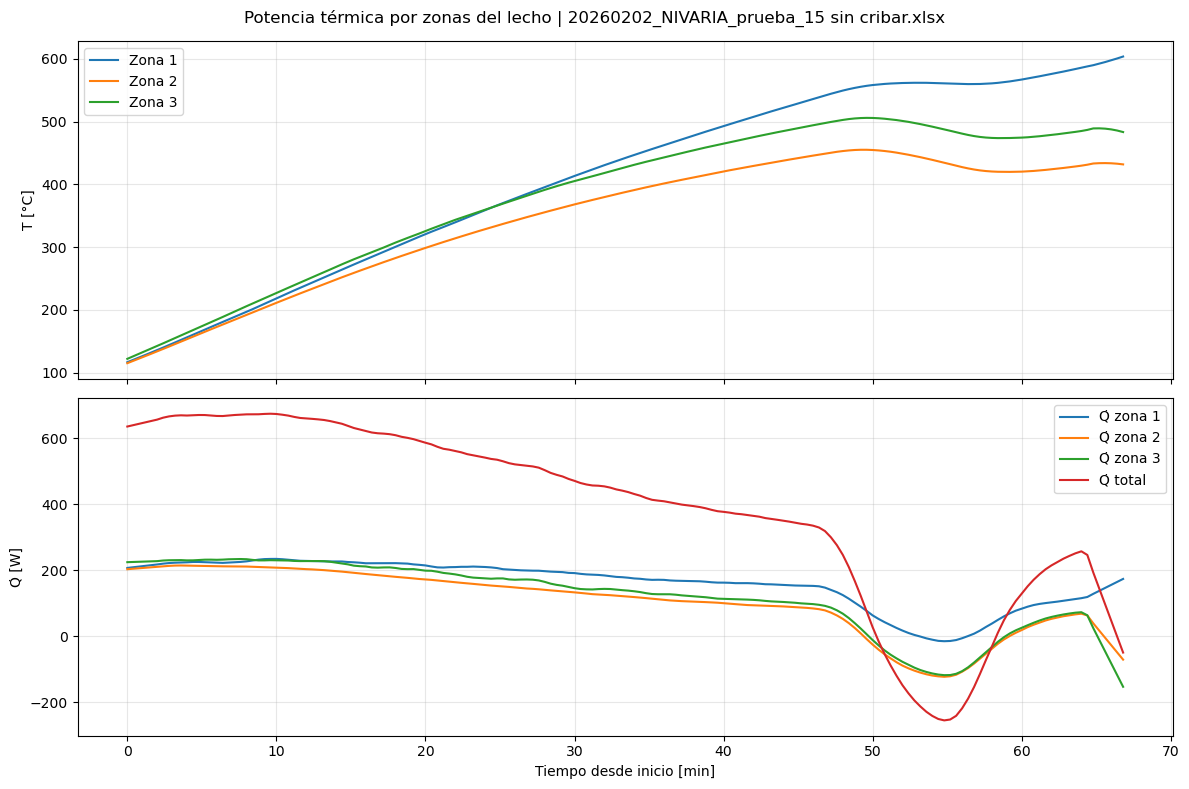

In [25]:
### 8.1 Analytical estimate — case 3

CASE3_IDX = 3
case3     = cases_pf[CASE3_IDX]

# Re-use the experimental data already stored in val_results
t_exp3_s = val_results[CASE3_IDX]["t_exp_s"]
T_exp3_K = val_results[CASE3_IDX]["T_exp_K"]

ri = Di / 2.0
ro = Do / 2.0

zone_df3 = compute_bed_zone_power(
    case3,
    data_key="process_pre_flow",
    temp_cols={
        "T_z1": "Temp_aire-Ten_TG_1",
        "T_z2": "Temp_aire-Ten_TG_2",
        "T_z3": "Temp_aire-Ten_TG_3",
    },
    L_m=L, ri_m=ri, ro_m=ro,
    rho_wall_kg_m3=7900.0,
    cp_wall_J_kg_K=500.0,
    zone_length_m=dz,
    smooth_window=11,
    polyorder=2,
)

frac_start, frac_end = 0.15, 0.85
n3 = len(zone_df3)
i0, i1 = int(n3 * frac_start), int(n3 * frac_end)

Q_est3 = {
    key: float(np.nanmean(zone_df3[f"Qdot_{key}_W"].iloc[i0:i1]))
    for key in ["z1", "z2", "z3"]
}

print("Analytical power estimate — case 3:")
print(f"  Q_zona_1 (TG_1) : {Q_est3['z1']:+.1f} W")
print(f"  Q_zona_2 (TG_2) : {Q_est3['z2']:+.1f} W")
print(f"  Q_zona_3 (TG_3) : {Q_est3['z3']:+.1f} W")
print(f"  Total estimado  : {sum(Q_est3.values()):+.1f} W")

fig, axes = plot_bed_zone_power(zone_df3, case_label=case3["file_name"])
plt.tight_layout()
plt.show()

Initial estimate:  Q_b=161.6 W   Q_m=101.4 W   Q_t=119.2 W
  Tw_init [K]: [397.4 395.7 403.3]   T_gas_init: 398.8 K
CPU: 79.0 s


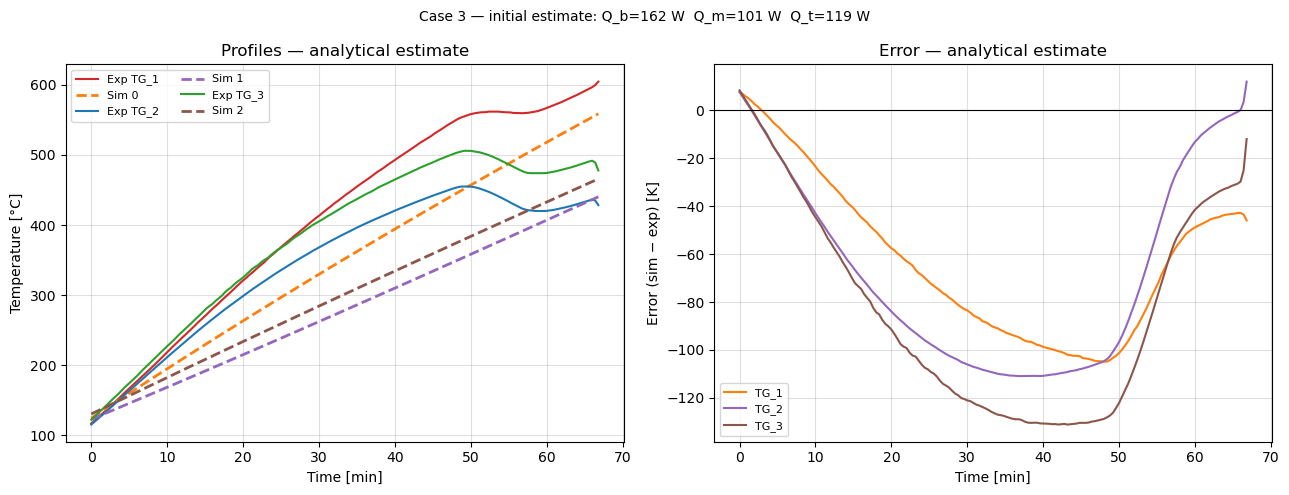

  RMSE TG_1: 70.21 K
  RMSE TG_2: 78.27 K
  RMSE TG_3: 92.93 K


In [26]:
### 8.2 Initial simulation with analytical estimate

Q3_0_b = max(Q_est3["z1"], 0.0)
Q3_0_m = max(Q_est3["z2"], 0.0)
Q3_0_t = max(Q_est3["z3"], 0.0)

print(f"Initial estimate:  Q_b={Q3_0_b:.1f} W   Q_m={Q3_0_m:.1f} W   Q_t={Q3_0_t:.1f} W")

t0_cpu = time.perf_counter()
_, _, t_sim3_0, h3_0, cpu3_0 = simulate_case(case3, Q3_0_b, Q3_0_m, Q3_0_t)
print(f"CPU: {cpu3_0:.1f} s")

# Comparison plot
clr_exp = ["#d62728", "#1f77b4", "#2ca02c"]
clr_sim = ["#ff7f0e", "#9467bd", "#8c564b"]
tg_keys = ["TG_1", "TG_2", "TG_3"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
for i, key in enumerate(tg_keys):
    ax.plot(t_exp3_s / 60.0, T_exp3_K[key] - 273.15, color=clr_exp[i], lw=1.5, label=f"Exp {key}")
    ax.plot(t_sim3_0 / 60.0, h3_0._Tw_results[:, i] - 273.15, color=clr_sim[i], lw=2.0, ls="--", label=f"Sim {i}")
ax.set_xlabel("Time [min]"); ax.set_ylabel("Temperature [°C]")
ax.set_title("Profiles — analytical estimate"); ax.grid(True, alpha=0.4); ax.legend(fontsize=8, ncol=2)

ax = axes[1]
for i, key in enumerate(tg_keys):
    T_sim_i = np.interp(t_exp3_s, t_sim3_0, h3_0._Tw_results[:, i])
    err = T_sim_i - T_exp3_K[key]; valid = np.isfinite(err)
    ax.plot(t_exp3_s[valid] / 60.0, err[valid], color=clr_sim[i], lw=1.5, label=key)
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("Time [min]"); ax.set_ylabel("Error (sim − exp) [K]")
ax.set_title("Error — analytical estimate"); ax.grid(True, alpha=0.4); ax.legend(fontsize=8)

fig.suptitle(f"Case 3 — initial estimate: Q_b={Q3_0_b:.0f} W  Q_m={Q3_0_m:.0f} W  Q_t={Q3_0_t:.0f} W", fontsize=10)
plt.tight_layout(); plt.show()

for i, key in enumerate(tg_keys):
    T_sim_i = np.interp(t_exp3_s, t_sim3_0, h3_0._Tw_results[:, i])
    err = T_sim_i - T_exp3_K[key]; valid = np.isfinite(err)
    print(f"  RMSE {key}: {np.sqrt(np.mean(err[valid]**2)):.2f} K")

In [27]:
### 8.3 Optimisation — case 3

_eval_count3 = [0]


def objective3(x):
    """RMSE between simulated Tw and measured temperatures for case 3."""
    Q_b, Q_m, Q_t = float(x[0]), float(x[1]), float(x[2])

    penalty = 0.0
    if Q_b < 0:
        penalty += 1e4 * Q_b**2; Q_b = 0.0
    if Q_m < 0:
        penalty += 1e4 * Q_m**2; Q_m = 0.0
    if Q_t < 0:
        penalty += 1e4 * Q_t**2; Q_t = 0.0

    try:
        _, _, t_sim, h, _ = simulate_case(case3, Q_b, Q_m, Q_t)
    except Exception as e:
        print(f"  ERROR: {e}")
        return 1e10

    sse, n_pts = 0.0, 0
    for i, key in enumerate(["TG_1", "TG_2", "TG_3"]):
        T_sim_i = np.interp(t_exp3_s, t_sim, h._Tw_results[:, i])
        err = T_sim_i - T_exp3_K[key]; valid = np.isfinite(err)
        sse   += float(np.sum(err[valid]**2))
        n_pts += int(np.sum(valid))

    rmse = float(np.sqrt(sse / max(n_pts, 1)))
    _eval_count3[0] += 1
    if _eval_count3[0] % 10 == 0:
        print(f"  Eval {_eval_count3[0]:4d}: Q=[{Q_b:.1f}, {Q_m:.1f}, {Q_t:.1f}] W  →  RMSE={rmse:.3f} K")

    return rmse + penalty


print("Evaluating at analytical estimate:")
_eval_count3[0] = 0
rmse3_0 = objective3([Q3_0_b, Q3_0_m, Q3_0_t])
print(f"  RMSE initial: {rmse3_0:.3f} K")
print()
print("Starting Nelder-Mead optimisation (3 free parameters)...")

_eval_count3[0] = 0
t_opt3_start = time.perf_counter()

result3 = minimize(
    objective3,
    x0=[Q3_0_b, Q3_0_m, Q3_0_t],
    method="Nelder-Mead",
    options={"maxiter": 500, "xatol": 1.0, "fatol": 0.05, "disp": True, "adaptive": True},
)

t_opt3_total = time.perf_counter() - t_opt3_start
Q3_opt_b, Q3_opt_m, Q3_opt_t = [max(v, 0.0) for v in result3.x]

print(f"\nOptimisation completed in {t_opt3_total:.1f} s  ({_eval_count3[0]} evaluations)")
print()
print("Optimal heater powers — case 3:")
print(f"  Q_bottom (cell 0, TG_1) = {Q3_opt_b:.1f} W")
print(f"  Q_middle (cell 1, TG_2) = {Q3_opt_m:.1f} W")
print(f"  Q_top    (cell 2, TG_3) = {Q3_opt_t:.1f} W")
print(f"  Total                   = {Q3_opt_b + Q3_opt_m + Q3_opt_t:.1f} W")
print(f"\nOptimal RMSE: {result3.fun:.3f} K")

Evaluating at analytical estimate:
  Tw_init [K]: [397.4 395.7 403.3]   T_gas_init: 398.8 K
  RMSE initial: 81.017 K

Starting Nelder-Mead optimisation (3 free parameters)...
  Tw_init [K]: [397.4 395.7 403.3]   T_gas_init: 398.8 K
  Tw_init [K]: [397.4 395.7 403.3]   T_gas_init: 398.8 K
  Tw_init [K]: [397.4 395.7 403.3]   T_gas_init: 398.8 K
  Tw_init [K]: [397.4 395.7 403.3]   T_gas_init: 398.8 K
  Tw_init [K]: [397.4 395.7 403.3]   T_gas_init: 398.8 K
  Tw_init [K]: [397.4 395.7 403.3]   T_gas_init: 398.8 K
  Tw_init [K]: [397.4 395.7 403.3]   T_gas_init: 398.8 K
  Tw_init [K]: [397.4 395.7 403.3]   T_gas_init: 398.8 K
  Tw_init [K]: [397.4 395.7 403.3]   T_gas_init: 398.8 K
  Tw_init [K]: [397.4 395.7 403.3]   T_gas_init: 398.8 K
  Eval   10: Q=[180.2, 104.5, 128.7] W  →  RMSE=68.415 K
  Tw_init [K]: [397.4 395.7 403.3]   T_gas_init: 398.8 K
  Tw_init [K]: [397.4 395.7 403.3]   T_gas_init: 398.8 K
  Tw_init [K]: [397.4 395.7 403.3]   T_gas_init: 398.8 K
  Tw_init [K]: [397.4 395.7

  Tw_init [K]: [397.4 395.7 403.3]   T_gas_init: 398.8 K
CPU: 59.3 s


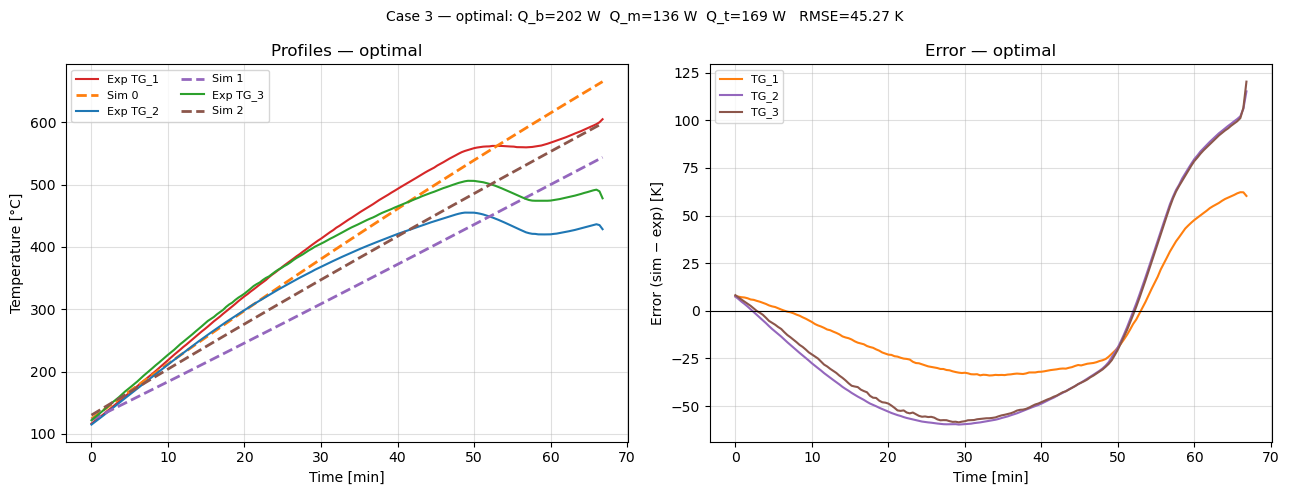

Per-zone metrics:
  TG_1: RMSE=29.71 K  Bias=-6.97 K
  TG_2: RMSE=52.03 K  Bias=-15.28 K
  TG_3: RMSE=50.59 K  Bias=-13.91 K


In [28]:
### 8.4 Simulation with optimal parameters — case 3

_, _, t_sim3_opt, h3_opt, cpu3_opt = simulate_case(case3, Q3_opt_b, Q3_opt_m, Q3_opt_t)
print(f"CPU: {cpu3_opt:.1f} s")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
for i, key in enumerate(tg_keys):
    ax.plot(t_exp3_s / 60.0, T_exp3_K[key] - 273.15, color=clr_exp[i], lw=1.5, label=f"Exp {key}")
    ax.plot(t_sim3_opt / 60.0, h3_opt._Tw_results[:, i] - 273.15, color=clr_sim[i], lw=2.0, ls="--", label=f"Sim {i}")
ax.set_xlabel("Time [min]"); ax.set_ylabel("Temperature [°C]")
ax.set_title("Profiles — optimal"); ax.grid(True, alpha=0.4); ax.legend(fontsize=8, ncol=2)

ax = axes[1]
for i, key in enumerate(tg_keys):
    T_sim_i = np.interp(t_exp3_s, t_sim3_opt, h3_opt._Tw_results[:, i])
    err = T_sim_i - T_exp3_K[key]; valid = np.isfinite(err)
    ax.plot(t_exp3_s[valid] / 60.0, err[valid], color=clr_sim[i], lw=1.5, label=key)
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("Time [min]"); ax.set_ylabel("Error (sim − exp) [K]")
ax.set_title("Error — optimal"); ax.grid(True, alpha=0.4); ax.legend(fontsize=8)

fig.suptitle(
    f"Case 3 — optimal: Q_b={Q3_opt_b:.0f} W  Q_m={Q3_opt_m:.0f} W  Q_t={Q3_opt_t:.0f} W"
    f"   RMSE={result3.fun:.2f} K",
    fontsize=10,
)
plt.tight_layout(); plt.show()

print("Per-zone metrics:")
for i, key in enumerate(tg_keys):
    T_sim_i = np.interp(t_exp3_s, t_sim3_opt, h3_opt._Tw_results[:, i])
    err = T_sim_i - T_exp3_K[key]; valid = np.isfinite(err)
    print(f"  {key}: RMSE={np.sqrt(np.mean(err[valid]**2)):.2f} K  Bias={np.mean(err[valid]):+.2f} K")

In [29]:
### 8.5 Export results — case 3

import pathlib

_results_dir = pathlib.Path(EXP) / "results"
_results_dir.mkdir(exist_ok=True)

_out3 = {
    "source_case_idx":  CASE3_IDX,
    "source_case_file": case3["file_name"],
    "Q_bottom_W":       round(Q3_opt_b, 2),
    "Q_middle_W":       round(Q3_opt_m, 2),
    "Q_top_W":          round(Q3_opt_t, 2),
    "Q_total_W":        round(Q3_opt_b + Q3_opt_m + Q3_opt_t, 2),
    "RMSE_K":           round(float(result3.fun), 4),
    "n_evaluations":    _eval_count3[0],
}

_path3 = _results_dir / "step2_case3_heater_powers.json"
with open(_path3, "w") as f:
    json.dump(_out3, f, indent=2)

print(f"Saved to: {_path3}")
print()
print("=" * 62)
print("  COMPARISON — CASE 2 (step 1) vs CASE 3 (step 2)")
print("=" * 62)
print(f"  {'':20s}  {'Case 2':>10}  {'Case 3':>10}")
print(f"  {'-'*20}  {'-'*10}  {'-'*10}")
print(f"  {'Q_bottom [W]':20s}  {Q_OPT_B:>10.1f}  {Q3_opt_b:>10.1f}")
print(f"  {'Q_middle [W]':20s}  {Q_OPT_M:>10.1f}  {Q3_opt_m:>10.1f}")
print(f"  {'Q_top [W]':20s}  {Q_OPT_T:>10.1f}  {Q3_opt_t:>10.1f}")
print(f"  {'Q_total [W]':20s}  {Q_OPT_B+Q_OPT_M+Q_OPT_T:>10.1f}  {Q3_opt_b+Q3_opt_m+Q3_opt_t:>10.1f}")
print(f"  {'Fit RMSE [K]':20s}  {step1['RMSE_K']:>10.3f}  {result3.fun:>10.3f}")
print("=" * 62)

Saved to: C:\Users\MiguelCamaraSanz\OneDrive - Fundacion CIRCE\GITHUB\HEATER\experimentacion\results\step2_case3_heater_powers.json

  COMPARISON — CASE 2 (step 1) vs CASE 3 (step 2)
                            Case 2      Case 3
  --------------------  ----------  ----------
  Q_bottom [W]               206.7       202.2
  Q_middle [W]               130.3       136.3
  Q_top [W]                  165.6       169.3
  Q_total [W]                502.6       507.8
  Fit RMSE [K]               8.765      45.272
